# Pixel covariance visualization
This notebook loads the Jacobian, covariance and index files produced by COLMAP's `covariance_exporter` or the `BACovariance` API. It then computes the 2x2 pixel covariance for all observations in a given image and visualises its magnitude.

In [1]:
from pathlib import Path
import numpy as np
from scipy import sparse
import matplotlib.pyplot as plt
import pycolmap

ModuleNotFoundError: No module named 'pycolmap'

In [ ]:
# Paths to the exported files
data_dir = Path("/mnt/c/DevSoftware/COLMAP/source/colmap/build/project")
jac_path = data_dir / "sparse/results/jacobian.txt"
cov_path = data_dir / "sparse/results/covariance.txt"
index_path = data_dir / "sparse/results/index.txt"
obs_index_path = data_dir / "sparse/results/obs_index.txt"
model_path = data_dir / "sparse/optimized"
image_id = 4  # image to analyse

In [449]:
def read_sparse_matrix(path: Path) -> sparse.csr_matrix:
    with open(path) as f:
        rows, cols = map(int, f.readline().split())
        data, r, c = [], [], []
        for line in f:
            rr, cc, val = line.split()
            r.append(int(rr))
            c.append(int(cc))
            data.append(float(val))
    return sparse.csr_matrix((data, (r, c)), shape=(rows, cols))


def read_dense_matrix(path: Path) -> np.ndarray:
    return np.loadtxt(path)


def read_index(path: Path) -> dict[str, tuple[int, int]]:
    mapping = {}
    with open(path) as f:
        for line in f:
            name, start, size = line.split()
            mapping[name] = (int(start), int(size))
    return mapping


def read_obs_index(path: Path) -> list[tuple[int, int, int, int]]:
    entries = []
    with open(path) as f:
        for line in f:
            iid, idx, pid, row = map(int, line.split())
            entries.append((iid, idx, pid, row))
    return entries

In [450]:
J = read_sparse_matrix(jac_path)
C = read_dense_matrix(cov_path)
index = read_index(index_path)
obs_info = read_obs_index(obs_index_path)

rec = pycolmap.Reconstruction(model_path)
img = rec.images[image_id]
cam = rec.cameras[img.camera_id]
height, width = cam.height, cam.width

In [451]:
# Append pixel coordinates from the reconstruction
obs_info = [
    (iid, idx, pid, row, rec.images[iid].points2D[idx].xy)
    for iid, idx, pid, row in obs_info
]

In [452]:
vals = []
coords = []
for iid, _idx, pid, row_start, xy in obs_info:
    if iid != image_id:
        continue
    rows = slice(row_start, row_start + 2)
    cols: list[int] = []
    rot_s, rot_sz = index.get(f"pose_{iid}_rot", (0, 0))
    trans_s, trans_sz = index.get(f"pose_{iid}_trans", (0, 0))
    cols += list(range(rot_s, rot_s + rot_sz))
    cols += list(range(trans_s, trans_s + trans_sz))
    pt_key = f"point_{pid}"
    if pt_key in index:
        ps, psz = index[pt_key]
        if ps + psz <= C.shape[0]:
            cols += list(range(ps, ps + psz))
    J_block = J[rows, :][:, cols].toarray()
    C_sub = C[np.ix_(cols, cols)]
    cov = J_block @ C_sub @ J_block.T
    val = np.sqrt(np.diag(cov))
    val = (val[0]**2 + val[1]**2)**(1/2)
    vals.append(val)
    coords.append(xy)

In [453]:
vals = np.array(vals) 
print("min", vals.min(), "max", vals.max(), "mean", vals.mean())

min 340531.3740527552 max 580345.5124016639 mean 361096.48580216756


In [381]:
img_cov = np.zeros((height, width), dtype=float)
for (x, y), v in zip(coords, vals):
    xi, yi = int(round(y)), int(round(x))
    if 0 <= yi < height and 0 <= xi < width:
        img_cov[yi, xi] = v

In [382]:
img_cov.shape

(3024, 4032)

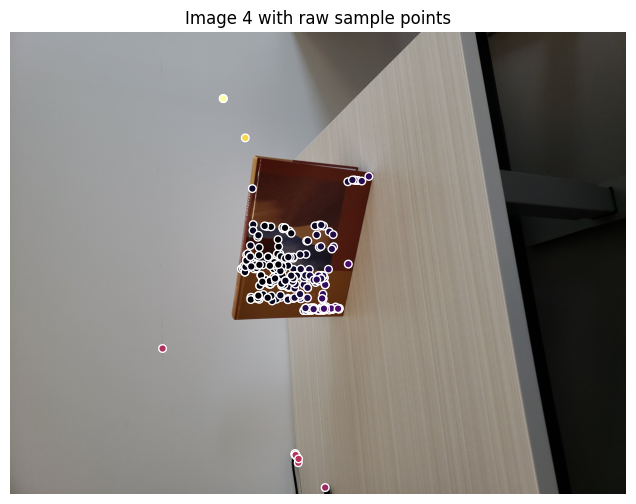

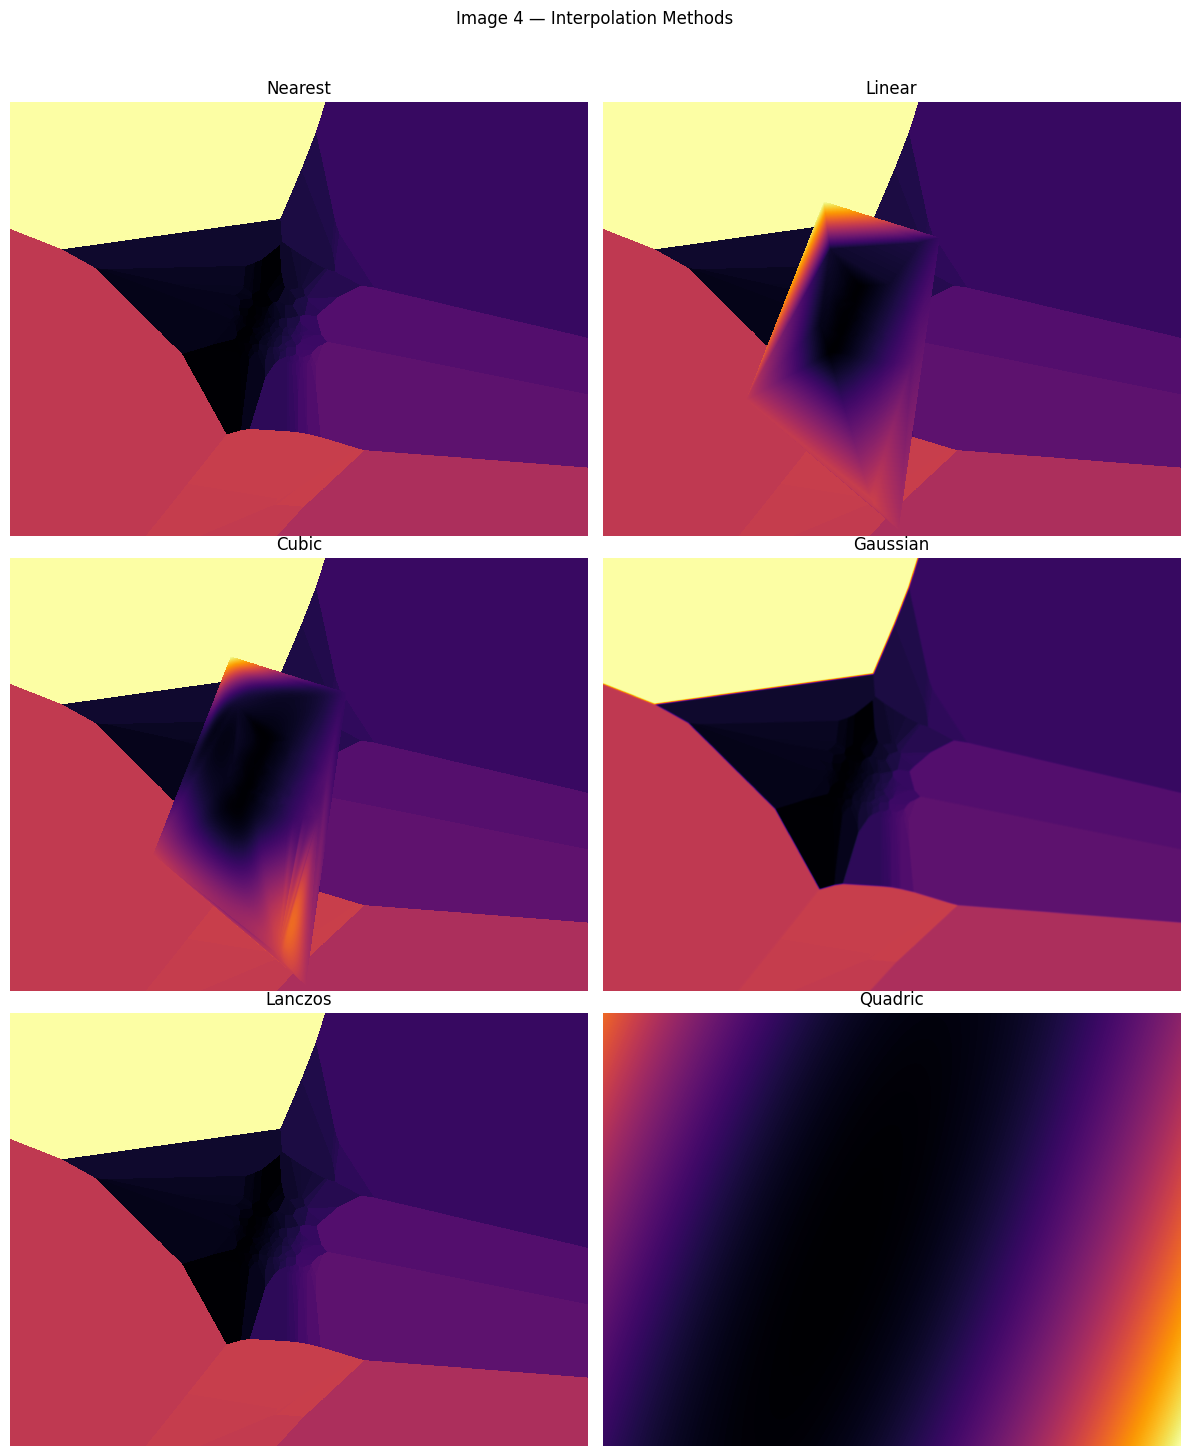

In [383]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from scipy.signal import convolve2d
from PIL import Image

# ── USER PARAMETERS ────────────────────────────────────────────────────────────
# coords: list of (x, y) sample positions
# vals:   list of covariance values at those positions
# img_idx: zero-based index for the 5th image (e.g., 4)
img_idx = image_id - 1 
# Direct WSL folder path
wsl_folder = "/mnt/c/DevSoftware/COLMAP/source/colmap/build/project/images"
# ──────────────────────────────────────────────────────────────────────────────

# Load the image
files = sorted([f for f in os.listdir(wsl_folder)
                if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff"))])
img_name = files[img_idx]
img_path = os.path.join(wsl_folder, img_name)
img = Image.open(img_path)
img_arr = np.array(img)
height, width = img_arr.shape[:2]

# Plot raw sample points on the true image
xs, ys = zip(*coords)
plt.figure(figsize=(8, 6))
plt.imshow(img_arr, origin="lower")
plt.scatter(xs, ys, c=vals, cmap="inferno", s=30, edgecolor="white")
plt.title(f"Image {img_idx+1} with raw sample points")
plt.axis("off")
plt.show()

# Filter outliers (central 99% interval)
vs = np.array(vals)
low_val, high_val = np.percentile(vs, [0.5, 99.5])
mask = (vs >= low_val) & (vs <= high_val)
pts = np.array(coords)[mask]
vals_f = vs[mask]

# Build full pixel grid
grid_x, grid_y = np.meshgrid(np.arange(width), np.arange(height))

# Interpolate via 6 methods (no reflection)
interps = {}

# nearest, linear, cubic
for m in ("nearest", "linear", "cubic"):
    if m == "nearest":
        g = griddata(pts, vals_f, (grid_x, grid_y), method=m)
    else:
        g = griddata(pts, vals_f, (grid_x, grid_y), method=m, fill_value=np.nan)
        nn = griddata(pts, vals_f, (grid_x, grid_y), method="nearest")
        g = np.where(np.isnan(g), nn, g)
    interps[m] = g

# Gaussian smoothing on the 'nearest' result
interps["gaussian"] = gaussian_filter(interps["nearest"], sigma=5)

# Lanczos-style convolution on the 'nearest' result
def lanczos_kernel(a, x):
    return np.sinc(x) * np.sinc(x/a) * (np.abs(x) < a)

a = 3
xk = np.arange(-a+1, a)
k1 = lanczos_kernel(a, xk)
k2 = np.outer(k1, k1)
k2 /= k2.sum()
interps["lanczos"] = convolve2d(interps["nearest"], k2, mode="same", boundary="symm")

# Quadric (2nd-degree polynomial) surface fit
X = np.column_stack([
    np.ones(len(vals_f)),
    pts[:, 0],
    pts[:, 1],
    pts[:, 0]**2,
    pts[:, 0]*pts[:, 1],
    pts[:, 1]**2
])
coeffs = np.linalg.lstsq(X, vals_f, rcond=None)[0]
grid_pts = np.column_stack([
    np.ones(grid_x.size),
    grid_x.ravel(),
    grid_y.ravel(),
    grid_x.ravel()**2,
    grid_x.ravel()*grid_y.ravel(),
    grid_y.ravel()**2
])
quadric = grid_pts.dot(coeffs).reshape(grid_x.shape)
interps["quadric"] = quadric

# Plot all 6 in a 3×2 grid (N rows × 2 columns)
methods = ["nearest", "linear", "cubic", "gaussian", "lanczos", "quadric"]
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(12, 15))
for ax, m in zip(axs.flat, methods):
    im = ax.imshow(interps[m], origin="lower", cmap="inferno", interpolation="nearest")
    ax.set_title(m.capitalize())
    ax.axis("off")

# Adjust layout to accommodate the suptitle without warning
fig.suptitle(f"Image {img_idx+1} — Interpolation Methods", y=0.97)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



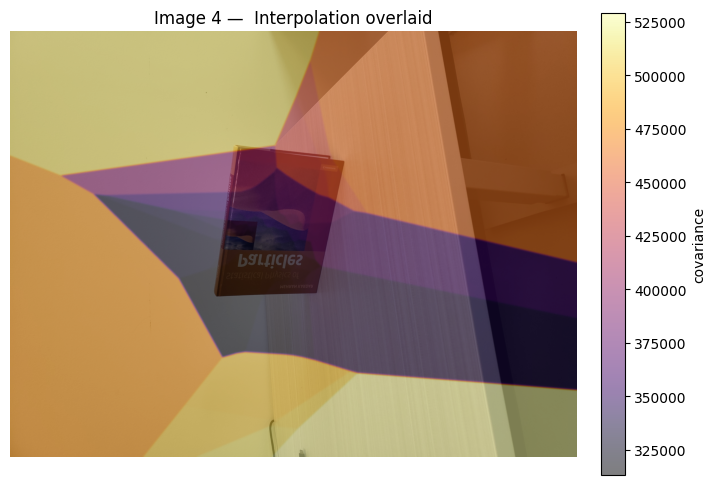

In [355]:

# Overlay a interpolation on the original image
plt.figure(figsize=(8, 6))
plt.imshow(img_arr, origin="lower")
ol = plt.imshow(interps["gaussian"], origin="lower", cmap="inferno", alpha=0.5, interpolation="gaussian")
plt.title(f"Image {img_idx+1} —  Interpolation overlaid")
plt.axis("off")
plt.colorbar(ol, label="covariance", fraction=0.046, pad=0.04)
plt.show()

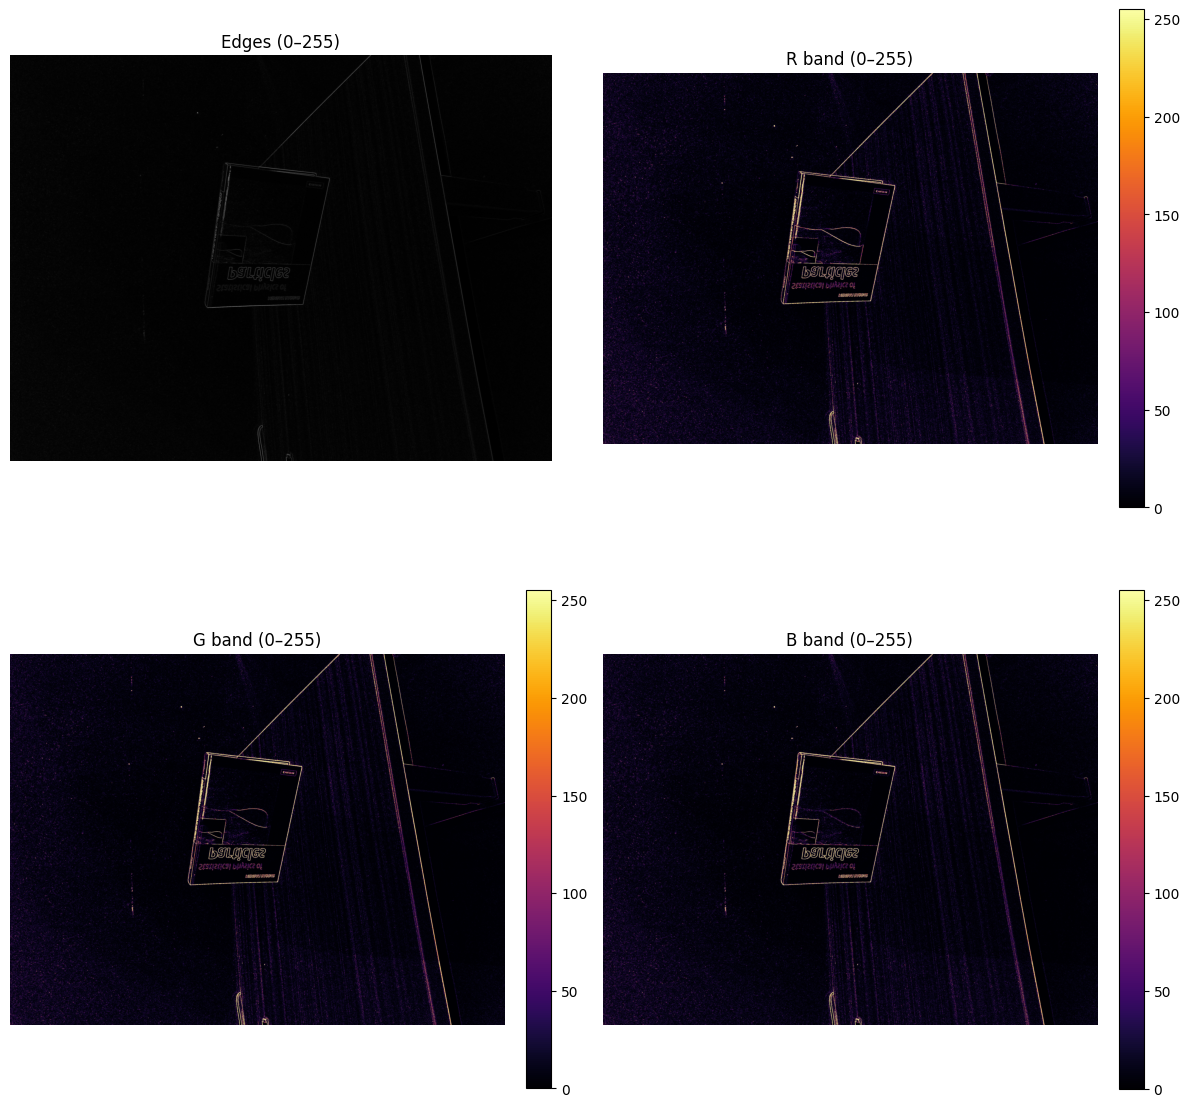

In [356]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.ndimage import sobel
from PIL import Image

# ── USER PARAMETERS ────────────────────────────────────────────────────────────
# coords: list of (x, y) sample positions
# vals:   list of covariance values at those positions
img_idx = image_id - 1  # zero-based index for the 5th image
wsl_folder = "/mnt/c/DevSoftware/COLMAP/source/colmap/build/project/images"
# ──────────────────────────────────────────────────────────────────────────────

# 1) Load the chosen image
files = sorted([
    f for f in os.listdir(wsl_folder)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff"))
])
img_path = os.path.join(wsl_folder, files[img_idx])
img = Image.open(img_path)
img_arr = np.array(img)
height, width = img_arr.shape[:2]

# 2) Filter out sample‐value outliers (central 99% interval)
vs = np.array(vals)
low_val, high_val = np.percentile(vs, [0.5, 99.5])
mask = (vs >= low_val) & (vs <= high_val)
pts = np.array(coords)[mask]
vals_f = vs[mask]

# 3) Build full pixel grid
grid_x, grid_y = np.meshgrid(np.arange(width), np.arange(height))

# 4) Interpolate covariance via linear + nearest to fill
cov_interp = griddata(
    pts, vals_f,
    (grid_x, grid_y),
    method='linear',
    fill_value=np.nan
)
cov_interp = np.where(
    np.isnan(cov_interp),
    griddata(pts, vals_f, (grid_x, grid_y), method='nearest'),
    cov_interp
)

# 5) Compute Sobel gradients
gray = img_arr.mean(axis=2)
gx = sobel(gray, axis=1)
gy = sobel(gray, axis=0)
edge_mag = np.hypot(gx, gy)

# 6) Compute gradient‐covariance magnitude for each band
maps = {}
for i, band in enumerate(('R','G','B')):
    channel = img_arr[:,:,i].astype(float)
    gx_c = sobel(channel, axis=1)
    gy_c = sobel(channel, axis=0)
    maps[band] = cov_interp * (gx_c**2 + gy_c**2)

# 7) Remove outliers in each band map (clip to 0.5–99.5 percentile)
maps_clipped = {}
for band, arr in maps.items():
    p_low, p_high = np.percentile(arr, [0.5, 99.5])
    maps_clipped[band] = np.clip(arr, p_low, p_high)

# 8) Normalize to 0–255 for display
edge_min, edge_max = edge_mag.min(), edge_mag.max()
edge_scaled = (edge_mag - edge_min) / (edge_max - edge_min) * 255

maps_scaled = {}
for band, arr in maps_clipped.items():
    a_min, a_max = arr.min(), arr.max()
    maps_scaled[band] = (arr - a_min) / (a_max - a_min) * 255

# 9) Plot 2×2 grid: edges, R, G, B
fig, axs = plt.subplots(2, 2, figsize=(12, 12))

axs[0,0].imshow(edge_scaled, cmap='gray', vmin=0, vmax=255, origin='lower')
axs[0,0].set_title('Edges (0–255)')
axs[0,0].axis('off')

imr = axs[0,1].imshow(maps_scaled['R'], cmap='inferno', vmin=0, vmax=255, origin='lower')
axs[0,1].set_title('R band (0–255)')
axs[0,1].axis('off')
fig.colorbar(imr, ax=axs[0,1], fraction=0.046, pad=0.04)

img = axs[1,0].imshow(maps_scaled['G'], cmap='inferno', vmin=0, vmax=255, origin='lower')
axs[1,0].set_title('G band (0–255)')
axs[1,0].axis('off')
fig.colorbar(img, ax=axs[1,0], fraction=0.046, pad=0.04)

imb = axs[1,1].imshow(maps_scaled['B'], cmap='inferno', vmin=0, vmax=255, origin='lower')
axs[1,1].set_title('B band (0–255)')
axs[1,1].axis('off')
fig.colorbar(imb, ax=axs[1,1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()



If we have few object points we are intp over most of the image. Enhancing with dense matching might be valuable. There are also some very large values that have popped up, and I don't have great justification for addressing them one way or the other. Lastly, we are still several orders of magnitude off which I am not entirely sure how to address yet. 

However, I do think the broad idea is feasible, we just need to go a little deeper with how colmap is doing stuff. 